### Investicinių portfelių sudarymas

In [ ]:
# pasirenkamos europos akcijos
akcijos = [
    "ASML.AS",   # ASML Holding
    "SAP.DE",    # SAP
    "SIE.DE",    # Siemens
    "MC.PA",     # LVMH
    "TTE.PA",    # TotalEnergies
    "AIR.PA",    # Airbus
    "SAN.PA",    # Sanofi
    "NESN.SW",   # Nestlé
    "NOVO-B.CO", # Novo Nordisk
    "SAN.MC"     # Banco Santander 
]

print(akcijos)

['ASML.AS', 'SAP.DE', 'SIE.DE', 'MC.PA', 'TTE.PA', 'AIR.PA', 'SAN.PA', 'NESN.SW', 'NOVO-B.CO', 'SAN.MC']


In [1]:
# jav akcijos
akcijos = [
    "MSFT",  # Information Technology - Microsoft
    "JPM",   # Financials - JPMorgan Chase
    "XOM",   # Energy - Exxon Mobil
    "JNJ",   # Health Care - Johnson & Johnson
    "PG",    # Consumer Staples - Procter & Gamble
    "HD",    # Consumer Discretionary - Home Depot
    "CAT",   # Industrials - Caterpillar
    "LIN",   # Materials - Linde
    "AMT",   # Real Estate - American Tower
    "GOOGL"  # Communication Services - Alphabet
]
print(akcijos)

['MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'HD', 'CAT', 'LIN', 'AMT', 'GOOGL']


In [14]:
import warnings
warnings.filterwarnings("ignore", message="Timestamp\\.utcnow is deprecated")

import yfinance as yf
import pandas as pd

pradzia = "2016-01-01"
pabaiga = "2026-01-01"

duomenys = yf.download(
    akcijos,
    start=pradzia,
    end=pabaiga,
    interval="1d",
    progress=False,
    auto_adjust=True
)

kainos = duomenys["Close"].copy()

# pašalinamos visiškai tuščios eilutės
kainos = kainos.dropna(how="all")

# užpildomos pavienės trūkstamos reikšmės
kainos = kainos.ffill()

# pašalinamos akcijos, kuriose vis dar yra trūkstamų reikšmių
kainos = kainos.dropna(axis=1)

print("Likusios akcijos:", len(kainos.columns))
print("Akcijų sąrašas:", kainos.columns.tolist())

padalijimas = int(len(kainos) * 0.8)

train_kainos = kainos.iloc[:padalijimas]
test_kainos = kainos.iloc[padalijimas:]

# skaičiuojamos dieninės grąžos
train_grazos = train_kainos.pct_change().dropna()
test_grazos = test_kainos.pct_change().dropna()

print("Train grąžų pirmos 5 eilutės:")
print(train_grazos.head())

print("\nTest grąžų pirmos 5 eilutės:")
print(test_grazos.head())

print("\nTrain grąžų dydis:", train_grazos.shape)
print("Test grąžų dydis:", test_grazos.shape)

# metinės vidutinės grąžos ir kovariacijų matrica
vid_grazos = train_grazos.mean() * 252
kov_matrica = train_grazos.cov() * 252

print("\nMetinės vidutinės grąžos:")
print(vid_grazos)

print("\nKovariacijų matrica:")
print(kov_matrica)

Likusios akcijos: 10
Akcijų sąrašas: ['AMT', 'CAT', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LIN', 'MSFT', 'PG', 'XOM']
Train grąžų pirmos 5 eilutės:
Ticker           AMT       CAT     GOOGL        HD       JNJ       JPM  \
Date                                                                     
2016-01-05  0.019752 -0.010443  0.002752 -0.004883  0.004179  0.001729   
2016-01-06 -0.003549 -0.015755 -0.002889 -0.010350 -0.005054 -0.014436   
2016-01-07 -0.024934 -0.034431 -0.024140 -0.028509 -0.011654 -0.040439   
2016-01-08 -0.016491 -0.010166 -0.013617 -0.011962 -0.010684 -0.022399   
2016-01-11  0.002653 -0.028757  0.002955  0.015174 -0.006011 -0.001527   

Ticker           LIN      MSFT        PG       XOM  
Date                                                
2016-01-05 -0.003443  0.004562  0.003190  0.008521  
2016-01-06 -0.010067 -0.018165 -0.009667 -0.008321  
2016-01-07 -0.025025 -0.034783 -0.008734 -0.016006  
2016-01-08  0.000614  0.003067 -0.015678 -0.020202  
2016-01-11  0.006029 -0.

In [ ]:
import numpy as np
from scipy.optimize import minimize
nerizikingu_palukanu_norma = 0.02
aktyvu_skaicius = len(vid_grazos)

def portfelio_rodikliai(svoriai, vid_grazos, kov_matrica):
    portfelio_graza = np.sum(svoriai * vid_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def neigiamas_sharpe(svoriai, vid_grazos, kov_matrica, nerizikingu_palukanu_norma):
    portfelio_graza, portfelio_rizika = portfelio_rodikliai(svoriai, vid_grazos, kov_matrica)
    return -(portfelio_graza - nerizikingu_palukanu_norma) / portfelio_rizika


apribojimai = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})
ribos = tuple((0, 1) for _ in range(aktyvu_skaicius))
pradiniai_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

# optimizacija
optimizavimo_rezultatas = minimize(
    neigiamas_sharpe,
    pradiniai_svoriai,
    args=(vid_grazos, kov_matrica, nerizikingu_palukanu_norma),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)

optimalus_svoriai = optimizavimo_rezultatas.x
optimali_graza, optimali_rizika = portfelio_rodikliai(optimalus_svoriai, vid_grazos, kov_matrica)
optimalus_sharpe = (optimali_graza - nerizikingu_palukanu_norma) / optimali_rizika

print("\n=== Maksimalaus Sharpe rodiklio portfelis ===")
svoriai_lentele = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": optimalus_svoriai
})
print("\nOptimalūs svoriai:")
print(svoriai_lentele)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {optimali_graza:.4f}")
print(f"Metinė rizika (std): {optimali_rizika:.4f}")
print(f"Sharpe santykis: {optimalus_sharpe:.4f}")

# testavimas su testiniais duomenimis
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252
testo_graza, testo_rizika = portfelio_rodikliai(
    optimalus_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)
testo_sharpe = (testo_graza - nerizikingu_palukanu_norma) / testo_rizika
print("\n=== Ne imties testas ===")
print(f"Metinė grąža: {testo_graza:.4f}")
print(f"Metinė rizika: {testo_rizika:.4f}")
print(f"Sharpe santykis: {testo_sharpe:.4f}")


=== Maksimalaus Sharpe rodiklio portfelis ===

Optimalūs svoriai:
  Akcija        Svoris
0    AMT  0.000000e+00
1    CAT  2.420085e-01
2  GOOGL  3.540423e-17
3     HD  0.000000e+00
4    JNJ  5.753150e-18
5    JPM  4.770529e-17
6    LIN  2.040757e-01
7   MSFT  5.158509e-01
8     PG  3.806480e-02
9    XOM  0.000000e+00

Portfelio rodikliai:
Metinė grąža: 0.2649
Metinė rizika (std): 0.2240
Sharpe santykis: 1.0934

=== Ne imties testas ===
Metinė grąža: 0.1865
Metinė rizika: 0.1730
Sharpe santykis: 0.9622


In [17]:
# minimalios dispersijos portfelis
import numpy as np
from scipy.optimize import minimize

aktyvu_skaicius = len(vid_grazos)

def portfelio_rizika(svoriai, kov_matrica):
    return np.sqrt(np.dot(svoriai.T, np.dot(kov_matrica, svoriai)))

# apribojimas: svorių suma turi būti lygi 1
apribojimai = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

# svoriai tarp 0 ir 1, be short selling
ribos = tuple((0, 1) for _ in range(aktyvu_skaicius))

# pradinis spėjimas - vienodi svoriai
pradiniai_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

# optimizacija
minimalios_dispersijos_rezultatas = minimize(
    portfelio_rizika,
    pradiniai_svoriai,
    args=(kov_matrica,),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)

minimalios_dispersijos_svoriai = minimalios_dispersijos_rezultatas.x

# treniravimo rodikliai
minimalios_dispersijos_graza, minimalios_dispersijos_rizika = portfelio_rodikliai(
    minimalios_dispersijos_svoriai,
    vid_grazos,
    kov_matrica
)

minimalios_dispersijos_sharpe = (
    minimalios_dispersijos_graza - nerizikingu_palukanu_norma
) / minimalios_dispersijos_rizika

print("\n=== Minimalios dispersijos portfelis treniravimui ===")

svoriai_lentele_md = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": minimalios_dispersijos_svoriai
})

print("\nOptimalūs svoriai:")
print(svoriai_lentele_md)

print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {minimalios_dispersijos_graza:.4f}")
print(f"Metinė rizika: {minimalios_dispersijos_rizika:.4f}")
print(f"Sharpe santykis: {minimalios_dispersijos_sharpe:.4f}")

# bandymas su testiniais duomenimis
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_md, testo_rizika_md = portfelio_rodikliai(
    minimalios_dispersijos_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_md = (
    testo_graza_md - nerizikingu_palukanu_norma
) / testo_rizika_md

print("\n=== Minimalios dispersijos portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_md:.4f}")
print(f"Metinė rizika: {testo_rizika_md:.4f}")
print(f"Sharpe santykis: {testo_sharpe_md:.4f}")


=== Minimalios dispersijos portfelis treniravimui ===

Optimalūs svoriai:
  Akcija    Svoris
0    AMT  0.039191
1    CAT  0.001142
2  GOOGL  0.056101
3     HD  0.050277
4    JNJ  0.366600
5    JPM  0.000000
6    LIN  0.057008
7   MSFT  0.000000
8     PG  0.327232
9    XOM  0.102449

Portfelio rodikliai:
Metinė grąža: 0.1293
Metinė rizika: 0.1572
Sharpe santykis: 0.6953

=== Minimalios dispersijos portfelis testavimui ===
Metinė grąža: 0.1222
Metinė rizika: 0.1204
Sharpe santykis: 0.8495


In [18]:
# lygiasvoris portfelis

aktyvu_skaicius = len(vid_grazos)

lygus_svoriai = np.ones(aktyvu_skaicius) / aktyvu_skaicius

# treniravimo rodikliai
lygiasvorio_graza, lygiasvorio_rizika = portfelio_rodikliai(
    lygus_svoriai,
    vid_grazos,
    kov_matrica
)

lygiasvorio_sharpe = (
    lygiasvorio_graza - nerizikingu_palukanu_norma
) / lygiasvorio_rizika

print("\n=== Lygiasvoris portfelis treniravimui ===")

svoriai_lentele_lv = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": lygus_svoriai
})

print("\nOptimalūs svoriai (lygūs):")
print(svoriai_lentele_lv)

print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {lygiasvorio_graza:.4f}")
print(f"Metinė rizika: {lygiasvorio_rizika:.4f}")
print(f"Sharpe santykis: {lygiasvorio_sharpe:.4f}")

# lygiasvoris portfelis testavimui
testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_lv, testo_rizika_lv = portfelio_rodikliai(
    lygus_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_lv = (
    testo_graza_lv - nerizikingu_palukanu_norma
) / testo_rizika_lv

print("\n=== Lygiasvoris portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_lv:.4f}")
print(f"Metinė rizika: {testo_rizika_lv:.4f}")
print(f"Sharpe santykis: {testo_sharpe_lv:.4f}")


=== Lygiasvoris portfelis treniravimui ===

Optimalūs svoriai (lygūs):
  Akcija  Svoris
0    AMT     0.1
1    CAT     0.1
2  GOOGL     0.1
3     HD     0.1
4    JNJ     0.1
5    JPM     0.1
6    LIN     0.1
7   MSFT     0.1
8     PG     0.1
9    XOM     0.1

Portfelio rodikliai:
Metinė grąža: 0.1854
Metinė rizika: 0.1813
Sharpe santykis: 0.9124

=== Lygiasvoris portfelis testavimui ===
Metinė grąža: 0.1792
Metinė rizika: 0.1197
Sharpe santykis: 1.3294



=== Simuliacinis portfelis: didžiausia grąža prie ribotos rizikos ===
Metinė grąža: 0.2176
Metinė rizika: 0.1999
Sharpe santykis: 0.9883

Simuliacinio portfelio svoriai:
  Akcija    Svoris
0    AMT  0.196811
1    CAT  0.171010
2  GOOGL  0.131995
3     HD  0.022522
4    JNJ  0.029724
5    JPM  0.007261
6    LIN  0.097319
7   MSFT  0.250614
8     PG  0.014988
9    XOM  0.077757


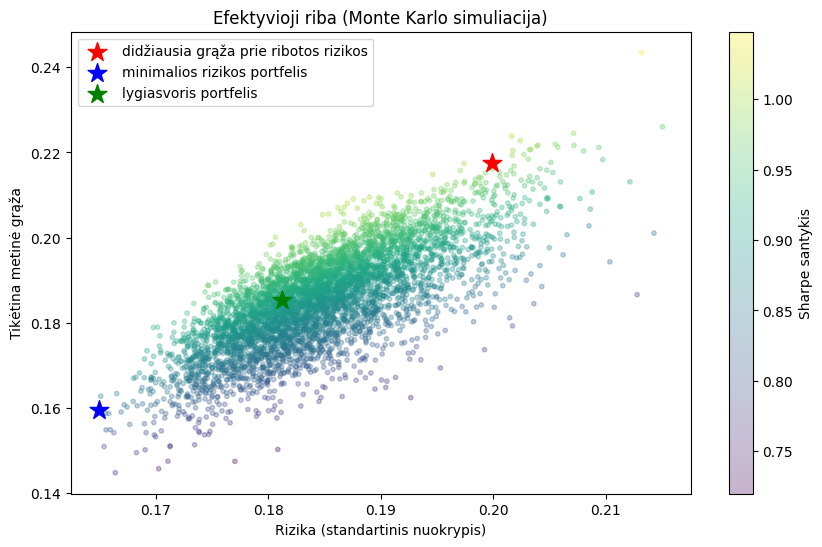

In [19]:
import matplotlib.pyplot as plt

# simuliacinis portfelis
simuliaciju_skaicius = 5000

# nustatoma maksimali leistina rizika
maksimali_leistina_rizika = 0.20

rezultatai = np.zeros((3, simuliaciju_skaicius))
visi_svoriai = []

for i in range(simuliaciju_skaicius):
    # atsitiktiniai svoriai
    svoriai = np.random.random(aktyvu_skaicius)
    svoriai /= np.sum(svoriai)
    visi_svoriai.append(svoriai)

    portfelio_graza, portfelio_rizika = portfelio_rodikliai(
        svoriai,
        vid_grazos,
        kov_matrica
    )

    sharpe_santykis = (
        portfelio_graza - nerizikingu_palukanu_norma
    ) / portfelio_rizika

    rezultatai[0, i] = portfelio_graza
    rezultatai[1, i] = portfelio_rizika
    rezultatai[2, i] = sharpe_santykis

# portfeliai, kurių rizika neviršija nustatytos ribos
galimi_indeksai = np.where(rezultatai[1, :] <= maksimali_leistina_rizika)[0]

if len(galimi_indeksai) > 0:
    geriausias_galimas_indeksas = galimi_indeksai[np.argmax(rezultatai[0, galimi_indeksai])]
else:
    geriausias_galimas_indeksas = np.argmin(rezultatai[1, :])

simuliacinio_portfelio_graza = rezultatai[0, geriausias_galimas_indeksas]
simuliacinio_portfelio_rizika = rezultatai[1, geriausias_galimas_indeksas]
simuliacinio_portfelio_sharpe = rezultatai[2, geriausias_galimas_indeksas]
simuliacinio_portfelio_svoriai = visi_svoriai[geriausias_galimas_indeksas]

# minimalios dispersijos portfelis iš simuliacijų
minimalios_rizikos_indeksas = np.argmin(rezultatai[1, :])
minimalios_rizikos_graza = rezultatai[0, minimalios_rizikos_indeksas]
minimalios_rizikos_rizika = rezultatai[1, minimalios_rizikos_indeksas]
minimalios_rizikos_sharpe = rezultatai[2, minimalios_rizikos_indeksas]
minimalios_rizikos_svoriai = visi_svoriai[minimalios_rizikos_indeksas]

print("\n=== Simuliacinis portfelis: didžiausia grąža prie ribotos rizikos ===")
print(f"Metinė grąža: {simuliacinio_portfelio_graza:.4f}")
print(f"Metinė rizika: {simuliacinio_portfelio_rizika:.4f}")
print(f"Sharpe santykis: {simuliacinio_portfelio_sharpe:.4f}")

simuliacinio_portfelio_lentele = pd.DataFrame({
    "Akcija": vid_grazos.index,
    "Svoris": simuliacinio_portfelio_svoriai
})

print("\nSimuliacinio portfelio svoriai:")
print(simuliacinio_portfelio_lentele)

# efektyvios ribos grafikas
plt.figure(figsize=(10, 6))
plt.scatter(
    rezultatai[1, :],
    rezultatai[0, :],
    c=rezultatai[2, :],
    cmap='viridis',
    marker='o',
    s=10,
    alpha=0.3
)

plt.colorbar(label='Sharpe santykis')

plt.scatter(
    simuliacinio_portfelio_rizika,
    simuliacinio_portfelio_graza,
    color='r',
    marker='*',
    s=200,
    label='didžiausia grąža prie ribotos rizikos'
)

plt.scatter(
    minimalios_rizikos_rizika,
    minimalios_rizikos_graza,
    color='b',
    marker='*',
    s=200,
    label='minimalios rizikos portfelis'
)

plt.scatter(
    lygiasvorio_rizika,
    lygiasvorio_graza,
    color='g',
    marker='*',
    s=200,
    label='lygiasvoris portfelis'
)

plt.title('Efektyvioji riba (Monte Karlo simuliacija)')
plt.xlabel('Rizika (standartinis nuokrypis)')
plt.ylabel('Tikėtina metinė grąža')
plt.legend()
plt.show()

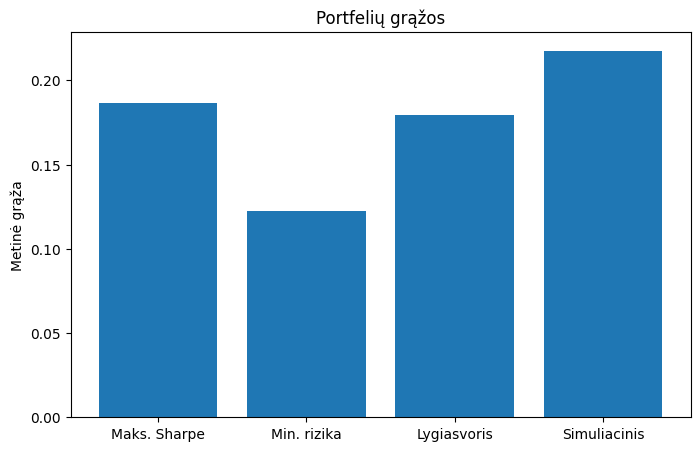

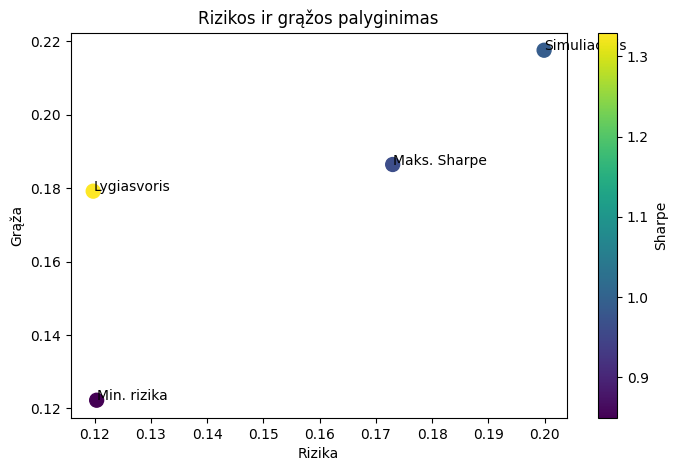

In [20]:
import matplotlib.pyplot as plt

pavadinimai = [
    "Maks. Sharpe",
    "Min. rizika",
    "Lygiasvoris",
    "Simuliacinis"
]

grazos = [
    testo_graza,
    testo_graza_md,
    testo_graza_lv,
    simuliacinio_portfelio_graza
]

rizikos = [
    testo_rizika,
    testo_rizika_md,
    testo_rizika_lv,
    simuliacinio_portfelio_rizika
]

sharpe = [
    testo_sharpe,
    testo_sharpe_md,
    testo_sharpe_lv,
    simuliacinio_portfelio_sharpe
]

plt.figure(figsize=(8, 5))
plt.bar(pavadinimai, grazos)
plt.ylabel("Metinė grąža")
plt.title("Portfelių grąžos")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(rizikos, grazos, c=sharpe, s=100)
for i in range(len(pavadinimai)):
    plt.text(rizikos[i], grazos[i], pavadinimai[i])
plt.xlabel("Rizika")
plt.ylabel("Grąža")
plt.title("Rizikos ir grąžos palyginimas")
plt.colorbar(label="Sharpe")
plt.show()

In [21]:
from skfolio.optimization import MaximumDiversification
import pandas as pd

mokymo_grazos = train_grazos

maksimalaus_diversifikavimo_modelis = MaximumDiversification()
maksimalaus_diversifikavimo_modelis.fit(mokymo_grazos)

maksimalaus_diversifikavimo_svoriai = maksimalaus_diversifikavimo_modelis.weights_

maksimalaus_diversifikavimo_lentele = pd.DataFrame({
    "Akcija": mokymo_grazos.columns,
    "Svoris": maksimalaus_diversifikavimo_svoriai
})

print("\n=== Maksimalaus diversifikavimo portfelis treniravimui ===")
print(maksimalaus_diversifikavimo_lentele)

maksimalaus_diversifikavimo_graza, maksimalaus_diversifikavimo_rizika = portfelio_rodikliai(
    maksimalaus_diversifikavimo_svoriai,
    vid_grazos,
    kov_matrica
)

maksimalaus_diversifikavimo_sharpe = (
    maksimalaus_diversifikavimo_graza - nerizikingu_palukanu_norma
) / maksimalaus_diversifikavimo_rizika

print("\nTreniravimo rodikliai:")
print(f"Metinė grąža: {maksimalaus_diversifikavimo_graza:.4f}")
print(f"Metinė rizika: {maksimalaus_diversifikavimo_rizika:.4f}")
print(f"Sharpe santykis: {maksimalaus_diversifikavimo_sharpe:.4f}")

testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_mdiv, testo_rizika_mdiv = portfelio_rodikliai(
    maksimalaus_diversifikavimo_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_mdiv = (
    testo_graza_mdiv - nerizikingu_palukanu_norma
) / testo_rizika_mdiv

print("\n=== Maksimalaus diversifikavimo portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_mdiv:.4f}")
print(f"Metinė rizika: {testo_rizika_mdiv:.4f}")
print(f"Sharpe santykis: {testo_sharpe_mdiv:.4f}")


=== Maksimalaus diversifikavimo portfelis treniravimui ===
  Akcija    Svoris
0    AMT  0.158801
1    CAT  0.097673
2  GOOGL  0.136019
3     HD  0.056921
4    JNJ  0.164270
5    JPM  0.013713
6    LIN  0.005439
7   MSFT  0.008790
8     PG  0.186383
9    XOM  0.171991

Treniravimo rodikliai:
Metinė grąža: 0.1552
Metinė rizika: 0.1698
Sharpe santykis: 0.7962

=== Maksimalaus diversifikavimo portfelis testavimui ===
Metinė grąža: 0.1648
Metinė rizika: 0.1151
Sharpe santykis: 1.2585


In [22]:
from skfolio.optimization import RiskBudgeting
from skfolio.measures import RiskMeasure
import pandas as pd

rizikos_pariteto_modelis = RiskBudgeting(
    risk_measure=RiskMeasure.VARIANCE,
    portfolio_params=dict(name="Rizikos paritetas")
)

rizikos_pariteto_modelis.fit(train_grazos)
rizikos_pariteto_svoriai = rizikos_pariteto_modelis.weights_

rizikos_pariteto_lentele = pd.DataFrame({
    "Akcija": train_grazos.columns,
    "Svoris": rizikos_pariteto_svoriai
})

print("\n=== Rizikos pariteto portfelis treniravimui ===")
print(rizikos_pariteto_lentele)

rizikos_pariteto_graza, rizikos_pariteto_rizika = portfelio_rodikliai(
    rizikos_pariteto_svoriai,
    vid_grazos,
    kov_matrica
)

rizikos_pariteto_sharpe = (
    rizikos_pariteto_graza - nerizikingu_palukanu_norma
) / rizikos_pariteto_rizika

print("\nTreniravimo rodikliai:")
print(f"Metinė grąža: {rizikos_pariteto_graza:.4f}")
print(f"Metinė rizika: {rizikos_pariteto_rizika:.4f}")
print(f"Sharpe santykis: {rizikos_pariteto_sharpe:.4f}")

testo_vid_grazos = test_grazos.mean() * 252
testo_kov_matrica = test_grazos.cov() * 252

testo_graza_rp, testo_rizika_rp = portfelio_rodikliai(
    rizikos_pariteto_svoriai,
    testo_vid_grazos,
    testo_kov_matrica
)

testo_sharpe_rp = (
    testo_graza_rp - nerizikingu_palukanu_norma
) / testo_rizika_rp

print("\n=== Rizikos pariteto portfelis testavimui ===")
print(f"Metinė grąža: {testo_graza_rp:.4f}")
print(f"Metinė rizika: {testo_rizika_rp:.4f}")
print(f"Sharpe santykis: {testo_sharpe_rp:.4f}")


=== Rizikos pariteto portfelis treniravimui ===
  Akcija    Svoris
0    AMT  0.102612
1    CAT  0.081950
2  GOOGL  0.087466
3     HD  0.093396
4    JNJ  0.141304
5    JPM  0.082072
6    LIN  0.093874
7   MSFT  0.083508
8     PG  0.138336
9    XOM  0.095484

Treniravimo rodikliai:
Metinė grąža: 0.1761
Metinė rizika: 0.1743
Sharpe santykis: 0.8953

=== Rizikos pariteto portfelis testavimui ===
Metinė grąža: 0.1646
Metinė rizika: 0.1142
Sharpe santykis: 1.2661
